In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.mixture import GaussianMixture

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
df = pd.read_csv("clean_data.csv")

print(df.shape)
df.head()

(8005, 60)


,Year,StateAbbr,StateDesc,CountyName,CountyFIPS,LocationName,DataSource,Category,Measure,Data_Value_Unit,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,2018,CA,California,Alameda,6001,6001400100,BRFSS,Health Outcomes,Current asthma among adults aged >=18 years,%,...,0.5,2.2,20.0,34.8,1543.0,80.6,6.6,12.8,0.0,4.0
1,2018,CA,California,Alameda,6001,6001400200,BRFSS,Health Outcomes,Current asthma among adults aged >=18 years,%,...,4.4,5.0,11.8,29.2,1231.0,77.4,10.2,11.6,0.8,3.7
2,2018,CA,California,Alameda,6001,6001400300,BRFSS,Health Outcomes,Current asthma among adults aged >=18 years,%,...,5.4,4.9,10.3,31.3,3213.0,73.0,17.8,9.2,0.0,5.5
3,2018,CA,California,Alameda,6001,6001400400,BRFSS,Health Outcomes,Current asthma among adults aged >=18 years,%,...,4.3,12.8,9.1,30.4,2499.0,73.9,15.2,10.7,0.3,5.0
4,2018,CA,California,Alameda,6001,6001400500,BRFSS,Health Outcomes,Current asthma among adults aged >=18 years,%,...,2.9,11.1,14.0,32.4,2587.0,77.1,14.1,8.8,0.0,2.6


Set Up - Q1

In 2018, what is the causal effect of high predicted PM2.5 levels on adult asthma prevalence in California?

Treatment variable: PM25_Treatment (derived from DS_PM_pred, binarized into "High"/"Low")

Outcome variable: Data_Value (asthma prevalence %, from CDC)

Potential confounders:

Race: White, Black, Hispanic, Asian, Native, Pacific

Gender: Men, Women

Income: Income, Poverty, IncomePerCap, ChildPoverty

Other socioeconomic controls: Employment, Commute, Education proxies (like Professional, Service, Construction, etc.)

This setup is suitable for Inverse Propensity Weighting (IPW) or matching to estimate the Average Treatment Effect (ATE) of high pollution exposure on asthma rates, controlling for those confounders.

Set Up - Q2

Can we predict air pollution levels (PM2.5) using asthma prevalence and socioeconomic/demographic indicators at the Census Block Group level in California (2018)?

Target variable: DS_PM_pred (predicted PM2.5 concentration)

Predictor variables:

Health outcome: Data_Value (asthma prevalence %)

Demographics:

Men, Women

White, Black, Hispanic, Asian, Native, Pacific

Socioeconomic variables:

Income, Poverty, IncomePerCap, ChildPoverty

Professional, Service, Office, Construction, Production

Employed, Unemployment

MeanCommute, Drive, Carpool, Transit, Walk, WorkAtHome

This aligns with exploratory environmental justice questions, for example: “Can we identify disproportionately polluted communities using social indicators and health disparities?”

<div style="page-break-after: always;"></div>

In [5]:
from sklearn.cluster import KMeans

pm_values = df[['DS_PM_pred']].copy()

kmeans = KMeans(n_clusters=2, random_state=42)
df['PM25_Cluster'] = kmeans.fit_predict(pm_values)

centroids = kmeans.cluster_centers_.flatten()
high_cluster = np.argmax(centroids)

df['PM25_Treatment'] = (df['PM25_Cluster'] == high_cluster).astype(int)

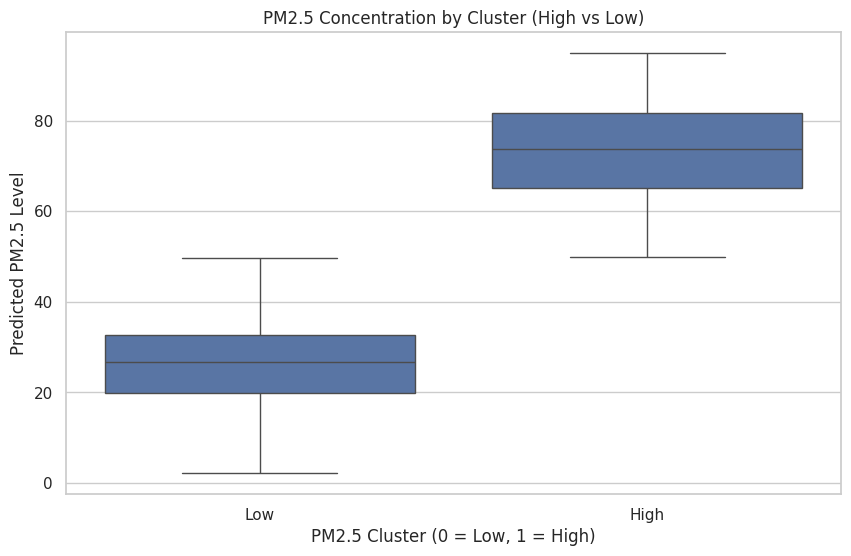

In [6]:
sns.boxplot(x='PM25_Treatment', y='DS_PM_pred', data=df)

plt.title('PM2.5 Concentration by Cluster (High vs Low)')
plt.xlabel('PM2.5 Cluster (0 = Low, 1 = High)')
plt.ylabel('Predicted PM2.5 Level')
plt.xticks([0, 1], ['Low', 'High'])

plt.show()

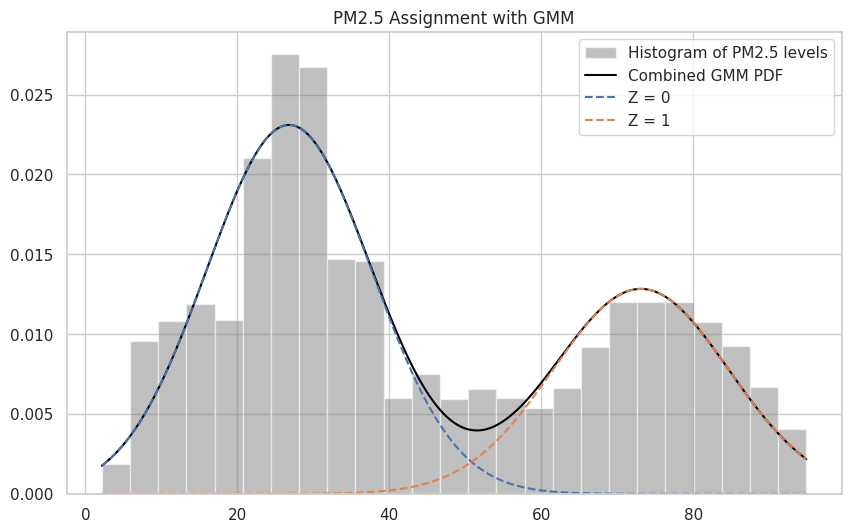

In [7]:
pm_gmm = df['DS_PM_pred'].to_numpy().reshape(-1, 1)

gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(pm_gmm)

counts, bins, _ = plt.hist(pm_gmm, bins=25, density=True, alpha=0.5, color="gray", label="Histogram of PM2.5 levels")

x = np.linspace(pm_gmm.min(), pm_gmm.max(), 1000).reshape(-1, 1)
pdf = np.exp(gmm.score_samples(x))
plt.plot(x, pdf, label="Combined GMM PDF", color="black")

for i in range(2):
    mean = gmm.means_[i][0]
    std = np.sqrt(gmm.covariances_[i][0][0])
    weight = gmm.weights_[i]
    component_pdf = weight * (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)
    plt.plot(x, component_pdf, "--", label=f"Z = {i}")

plt.legend()
plt.title("PM2.5 Assignment with GMM")
plt.show()

In [8]:
assignments = np.argmax(gmm.predict_proba(pm_gmm), axis=1)
df["Treatment_GMM"] = assignments

Text(0, 0.5, 'Asthma prevalence')

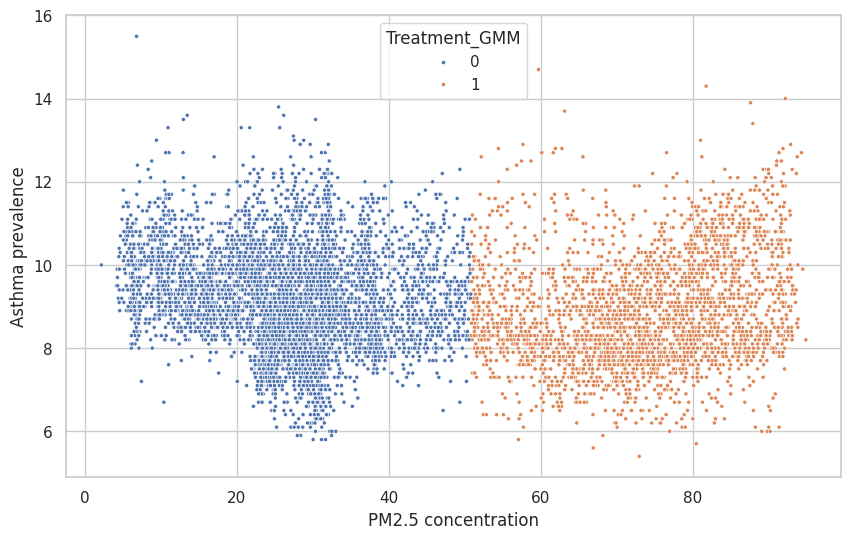

In [9]:
sns.scatterplot(data=df, x="DS_PM_pred", y="Data_Value", marker=".", hue="Treatment_GMM")
plt.xlabel("PM2.5 concentration")
plt.ylabel("Asthma prevalence")

Text(0.5, 0, 'Asthma prevalence')

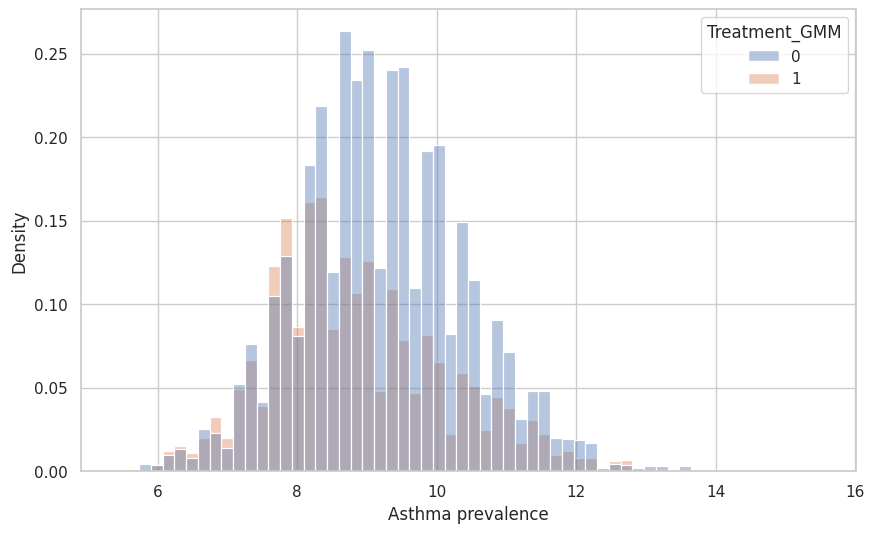

In [10]:
sns.histplot(data=df, stat="density", x="Data_Value", hue="Treatment_GMM", alpha=0.4)
plt.xlabel("Asthma prevalence")

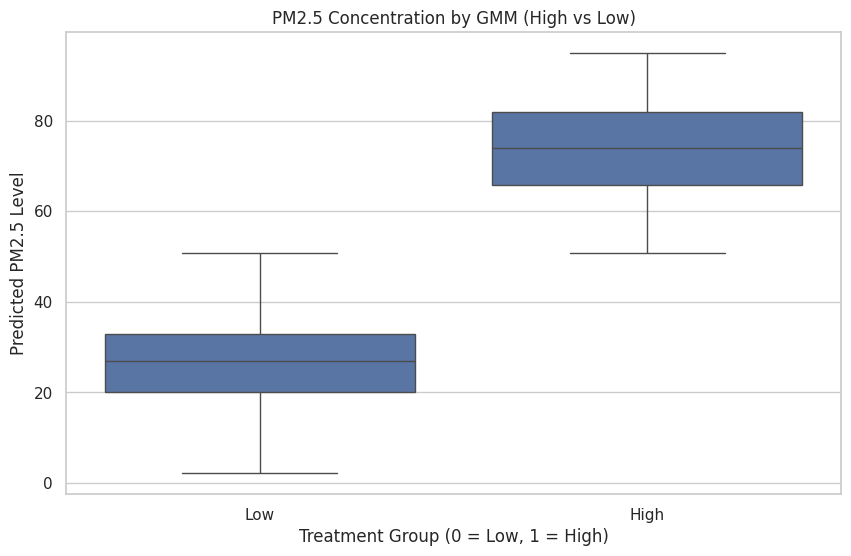

In [11]:
sns.boxplot(x='Treatment_GMM', y='DS_PM_pred', data=df)

plt.title('PM2.5 Concentration by GMM (High vs Low)')
plt.xlabel('Treatment Group (0 = Low, 1 = High)')
plt.ylabel('Predicted PM2.5 Level')
plt.xticks([0, 1], ['Low', 'High'])

plt.show()

Observations:

The plot clearly confirms that your PM2.5 clustering (into “High” and “Low”) is meaningful and distinct. The median PM2.5 level in the high cluster is substantially higher (around 75) than in the low cluster (around 28). There is little overlap in interquartile ranges (IQRs), which suggests strong separation between the two groups.

Relevance to Questions:

Q1: This clustering provides a binary treatment variable (High vs. Low PM2.5) necessary for methods like Inverse Propensity Weighting or matching. It validates that the treatment is not arbitrary—we’re distinguishing areas that truly differ in pollution exposure. This setup helps us estimate the causal effect of high PM2.5 on asthma while adjusting for confounders like race or gender.

<div style="page-break-after: always;"></div>

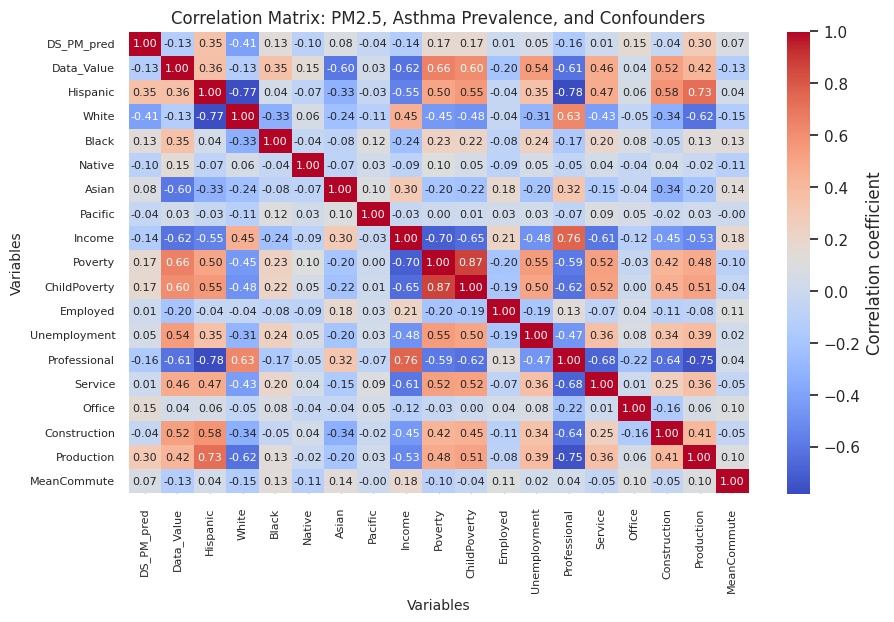

In [12]:
confounders = ['Hispanic', 'White', 'Black', 'Native', 'Asian', 'Pacific', 'Income',
               'Poverty', 'ChildPoverty', 'Employed', 'Unemployment', 'Professional',
               'Service', 'Office', 'Construction', 'Production', 'MeanCommute']

correlations = df[['DS_PM_pred', 'Data_Value'] + confounders].corr()
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8},
            cbar_kws={'label': 'Correlation coefficient'})
plt.title("Correlation Matrix: PM2.5, Asthma Prevalence, and Confounders", fontsize=12)
plt.xlabel('Variables', fontsize=10)
plt.ylabel('Variables', fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

Observations:

The first potential confounder is production, which are correlated with both income and asthma, which may influence modeling assumptions. Poverty and income are highly inversely correlated (-0.70), which is expected.

PM2.5 has negative correlation with income (-0.14), professional employment (-0.16). Positive correlation with poverty (0.17) and production sector employment (0.30). Suggests that lower-income, industrial communities may have higher pollution levels.

Relevance to Questions:

Q1: The matrix supports the presence of important confounders: prodcution, income, poverty, and race (Hispanic) are related both to PM2.5 exposure and asthma prevalence. These need to be carefully controlled for or stratified in causal models like IPW or matching.

Q2: Strong correlations with race (Hispanic), poverty, and employment sectors suggest that socioeconomic and demographic variables are informative predictors of pollution. We might consider feature selection guided by these correlations, and using regularization if multicollinearity becomes a modeling issue.

<div style="page-break-after: always;"></div>

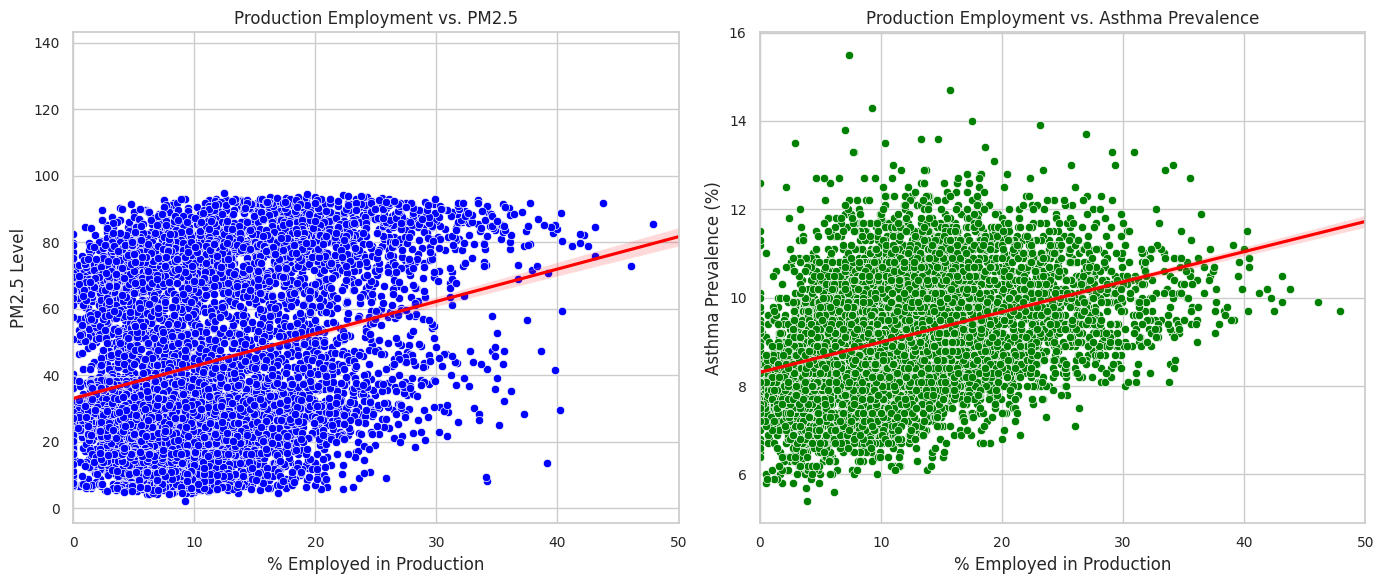

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=df, x='Production', y='DS_PM_pred', ax=axs[0], color='blue')
sns.regplot(data=df, x='Production', y='DS_PM_pred', ax=axs[0], scatter=False, color='blue', line_kws={'color': 'red'})
axs[0].set_title('Production Employment vs. PM2.5')
axs[0].set_xlabel('% Employed in Production')
axs[0].set_ylabel('PM2.5 Level')
axs[0].set_xlim(0, 50)
axs[0].tick_params(axis='both', which='major', labelsize=10)

sns.scatterplot(data=df, x='Production', y='Data_Value', ax=axs[1], color='green')
sns.regplot(data=df, x='Production', y='Data_Value', ax=axs[1], scatter=False, color='green', line_kws={'color': 'red'})
axs[1].set_title('Production Employment vs. Asthma Prevalence')
axs[1].set_xlabel('% Employed in Production')
axs[1].set_ylabel('Asthma Prevalence (%)')
axs[1].set_xlim(0, 50)
axs[1].tick_params(axis='both', which='major', labelsize=10)


plt.tight_layout()
plt.show()

Observations:

More industrial/production-based employment in an area is associated with higher predicted PM2.5 levels. This makes sense since industrial activity is a key source of particulate pollution. Areas with more production jobs lead to higher PM2.5, then higher asthma prevalence. This fits neatly into the causal chain.

Relevance to Questions:

Q1: These plots motivate the hypothesis that production-heavy areas may suffer worse asthma outcomes via increased pollution. Also motivates controlling for employment type in your causal analysis, as it may act as a confounder.

Q2: Since production employment is positively associated with PM2.5, it may serve as a predictive feature in our non-parametric models. Including sector-level employment variables could improve your model's socio-environmental interpretability.

<div style="page-break-after: always;"></div>

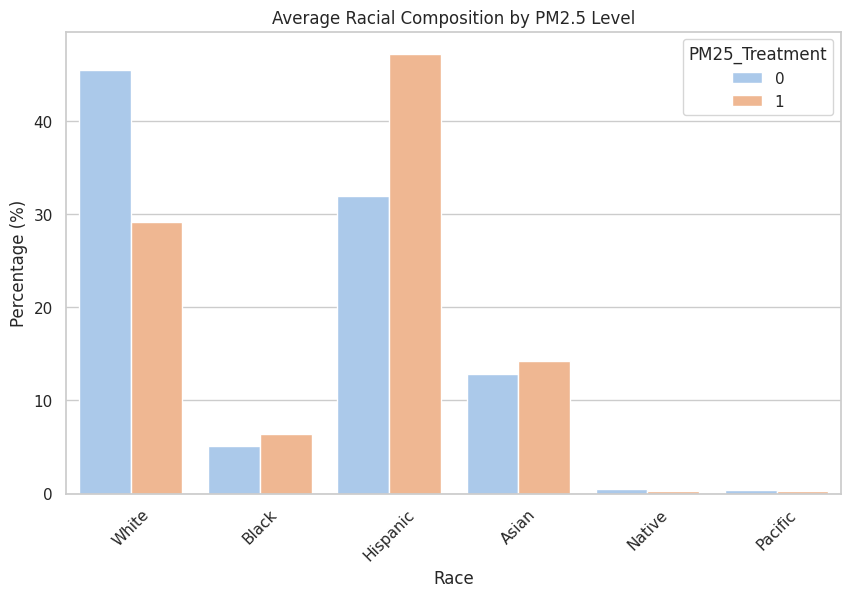

In [14]:
race_cols = ['White', 'Black', 'Hispanic', 'Asian', 'Native', 'Pacific']
race_df = df.groupby('PM25_Treatment')[race_cols].mean().reset_index().melt(id_vars='PM25_Treatment', var_name='Race', value_name='Percentage')

sns.barplot(data=race_df, x='Race', y='Percentage', hue='PM25_Treatment', palette='pastel')
plt.title("Average Racial Composition by PM2.5 Level")
plt.xticks(rotation=45)
plt.ylabel("Percentage (%)")
plt.show()

Observations:

Hispanic and Black populations are overrepresented in high PM2.5 areas. White populations are more prevalent in low PM2.5 areas. Asian representation is similar across both, but with slight variation.

Relevance to Both Questions:

This supports the idea that race/ethnicity is a confounding factor: differences in asthma prevalence could reflect environmental injustice, not just pollution. It justifies adjusting for race/ethnicity in both causal and predictive models. Also suggests structural disparities that could be a focus in policy-oriented discussions.
